In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from itertools import combinations
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.graph_objects as go
import matplotlib.colors as mcolors

In [2]:
fly_nums=[226,227,228,234,239,240,241,242,249,250]

In [3]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
behave_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/behave_all'
if not os.path.exists(behave_dir):
    os.mkdir(behave_dir)


In [4]:
# %%time
# for num in fly_nums:
#     fly_num = f'fly_{num}'
#     func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'
#     vision_path = os.path.join(func_path,'func_0', 'visual')

#     ### Load Photodiode ###
#     t, ft_triggers, pd1, pd2 = brainsss.load_photodiode(vision_path)
#     stimulus_start_times = brainsss.extract_stim_times_from_pd(pd1, t)
#     if stimulus_start_times.shape[0]<150:
#         stimulus_start_times = brainsss.extract_stim_times_from_pd(pd2, t)

#     # *100 puts in units of 10ms, which will match fictrac
#     st_10ms = [int(stimulus_start_times[i]*100) for i in range(len(stimulus_start_times))]

#     # get 1ms version to match neural timestamps
#     st_ms= [i*10 for i in st_10ms]
#     starts_loom = st_10ms
#     starts_loom_ms = [n*10 for n in starts_loom]
#     fictrac_path = os.path.join(func_path, 'func_0', 'fictrac')
#     fictrac_raw = brainsss.load_fictrac(fictrac_path)

#     fps = 100
#     resolution = 10 #desired resolution in ms
#     expt_len = fictrac_raw.shape[0]/fps*1000
#     behaviors = ['dRotLabY', 'dRotLabZ', 'dRotLabX']
#     fictrac = {}
#     for behavior in behaviors:
#         if behavior == 'dRotLabY': short = 'Y'
#         elif behavior == 'dRotLabZ': short = 'Z'
#         elif behavior == 'dRotLabX': short = 'X'
#         fictrac[short] = brainsss.smooth_and_interp_fictrac(fictrac_raw, fps, resolution, expt_len, behavior)
#     fictrac_timestamps = np.arange(0,expt_len,resolution)
#     pre_window = 200
#     post_window = 300
#     # avg_around = 20
#     stim_time = 100
#     # window = np.arange(-pre_window,post_window)

#     behavior_traces = {}
#     mean_trace = {}
#     sem_trace = {}
#     short=['Y', 'Z', 'X']
#     for s in short:
#         bt,mt,semt = brainsss.extract_traces(fictrac[s], starts_loom, pre_window, post_window)
#         behavior_traces[s] = bt
#         mean_trace[s] = mt
#         sem_trace[s] = semt
#     timestamps = brainsss.load_timestamps(os.path.join(func_path,'func_0', 'imaging'))
#     data_dict = {}
#     data_dict['timestamps'] = timestamps
#     data_dict['event_times'] = starts_loom_ms
#     data_dict['behavior'] = behavior_traces

#     dict_path = os.path.join(behave_dir, fly_num+'_behave_all.pkl')

#     with open(dict_path, 'wb') as file:
#         pickle.dump(data_dict, file)

In [5]:
for x in sorted(os.listdir(behave_dir)):
    print(x)

behavior_all.pkl
fly_226_behave_all.pkl
fly_227_behave_all.pkl
fly_228_behave_all.pkl
fly_234_behave_all.pkl
fly_239_behave_all.pkl
fly_240_behave_all.pkl
fly_241_behave_all.pkl
fly_242_behave_all.pkl
fly_249_behave_all.pkl
fly_250_behave_all.pkl


In [6]:
total_path = os.path.join(behave_dir, 'behavior_all.pkl')
redo=False
if os.path.exists(total_path)==False or redo==True:
    print("Making all fly behave dict")
    all_behave_dict = {}

    for x in sorted(os.listdir(behave_dir)):
        if 'fly' in x:
            fly_name= x[4:7]
            temp_path = os.path.join(behave_dir, x)
            with open(temp_path, 'rb') as file:
                dic = pickle.load(file)
                all_behave_dict[fly_name] = dic
    with open(total_path, 'wb') as file:
        pickle.dump(all_behave_dict, file)
else:
    print("Loading all fly behave dict")
    with open(total_path, 'rb') as file:
        all_behave_dict = pickle.load(file)

Loading all fly behave dict


In [7]:
print(all_behave_dict.keys())
print(all_behave_dict['226'].keys())
print(np.shape(all_behave_dict['226']['event_times']))
print(all_behave_dict['226']['behavior'].keys())

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['timestamps', 'event_times', 'behavior'])
(198,)
dict_keys(['Y', 'Z', 'X'])


In [8]:
highest_events=[]
for key in all_behave_dict:
    num_events=len(all_behave_dict[key]['behavior']['Y'])
    highest_events.append(num_events)
    print(f'{key} has {num_events}')
least=np.min(highest_events)
least

226 has 198
227 has 198
228 has 197
234 has 198
239 has 199
240 has 199
241 has 198
242 has 198
249 has 198
250 has 199


197

In [9]:
shape = least
for key in all_behave_dict:
    all_behave_dict[key]['behavior']['Y']=np.asarray(all_behave_dict[key]['behavior']['Y'][:shape,:])
    all_behave_dict[key]['behavior']['Z']=np.asarray(all_behave_dict[key]['behavior']['Z'][:shape,:])
    all_behave_dict[key]['behavior']['X']=np.asarray(all_behave_dict[key]['behavior']['X'][:shape,:])
    all_behave_dict[key]['event_times']=np.asarray(all_behave_dict[key]['event_times'][:shape])

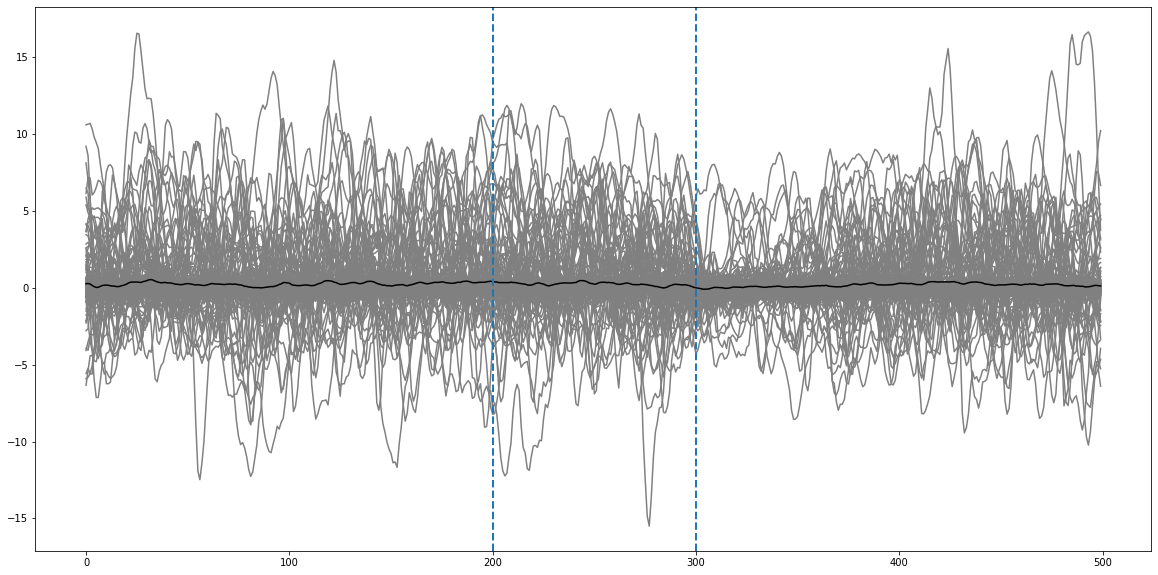

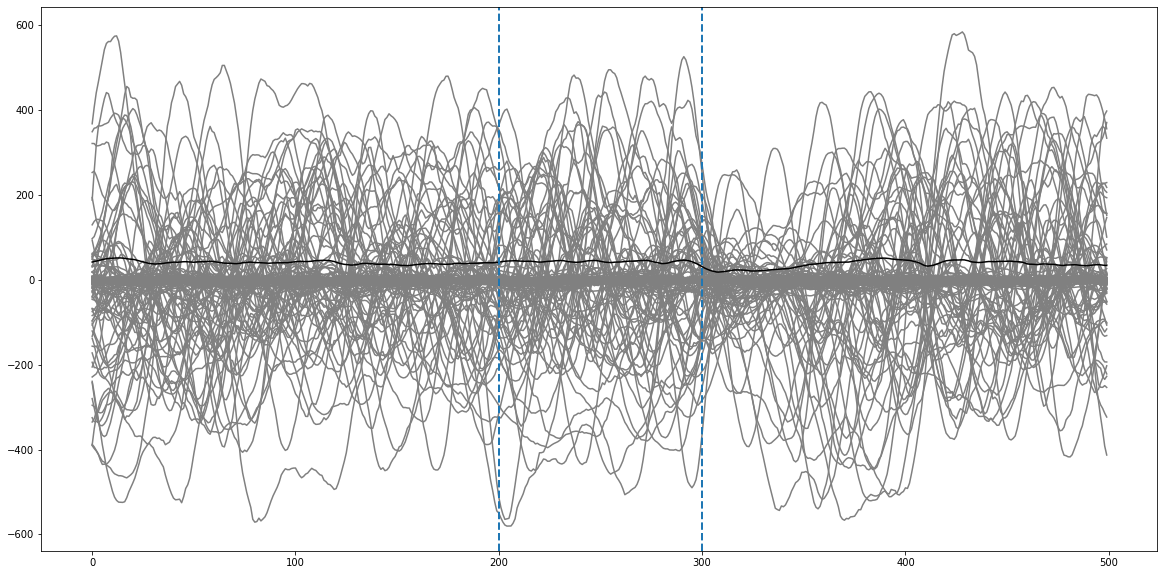

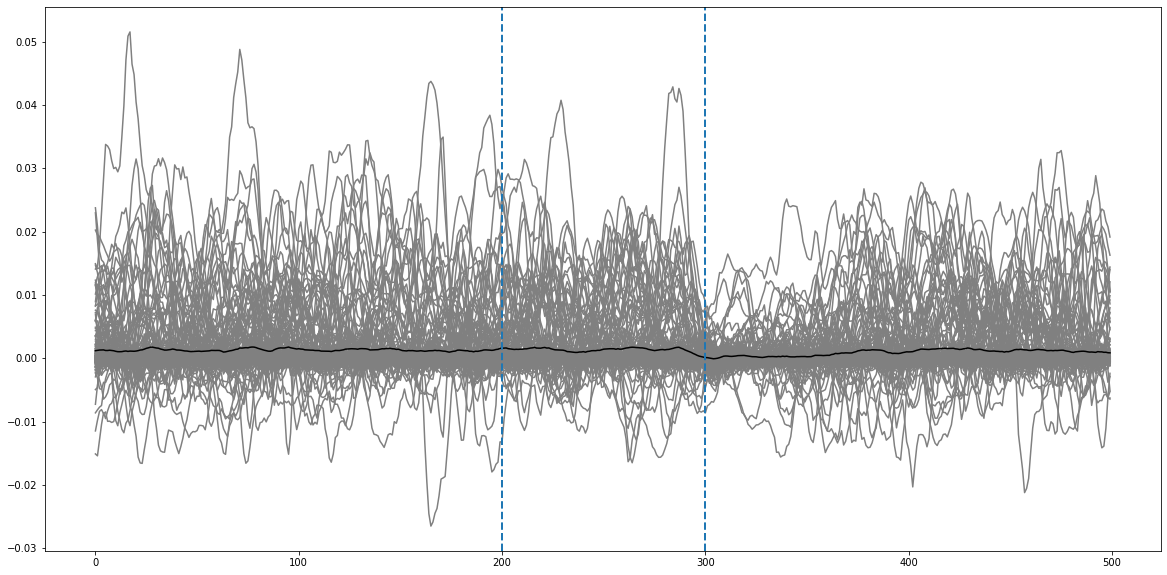

In [10]:
short=['Y', 'Z', 'X']
for s in short:
    fig, ax = plt.subplots(figsize=(20,10))
    plt.plot(all_behave_dict['250']['behavior'][s].T, c='Gray');
    if s=='Z':
        plt.plot(np.mean(np.abs(all_behave_dict['250']['behavior'][s]), axis=0).T, c='k');
    else:
        plt.plot(np.mean(all_behave_dict['250']['behavior'][s], axis=0).T, c='k');
    ax.axvline(200, linewidth=2, linestyle='--')
    ax.axvline(300, linewidth=2, linestyle='--')

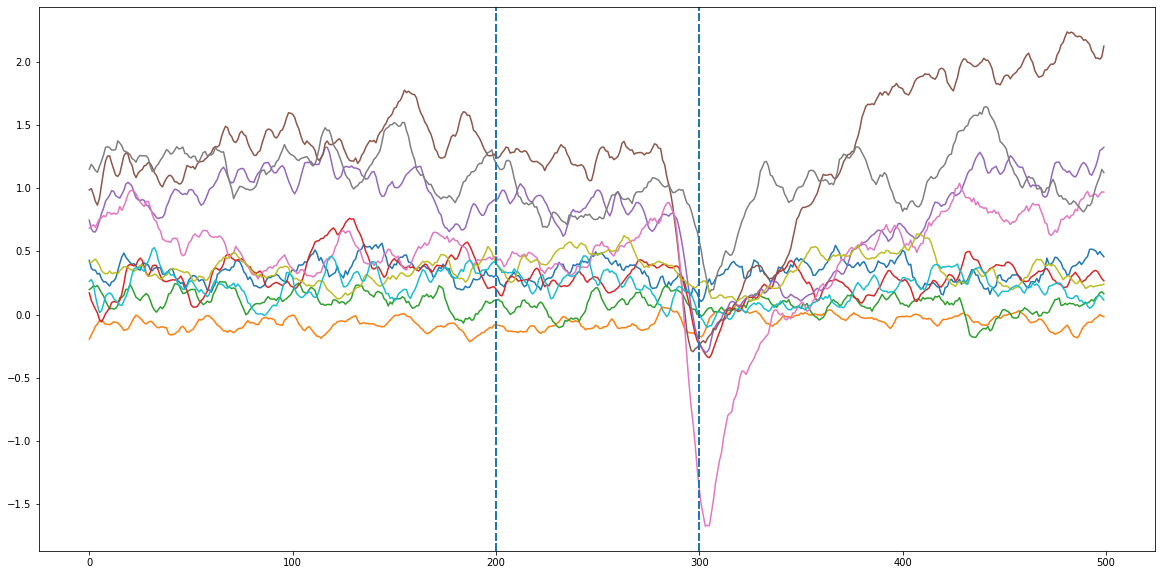

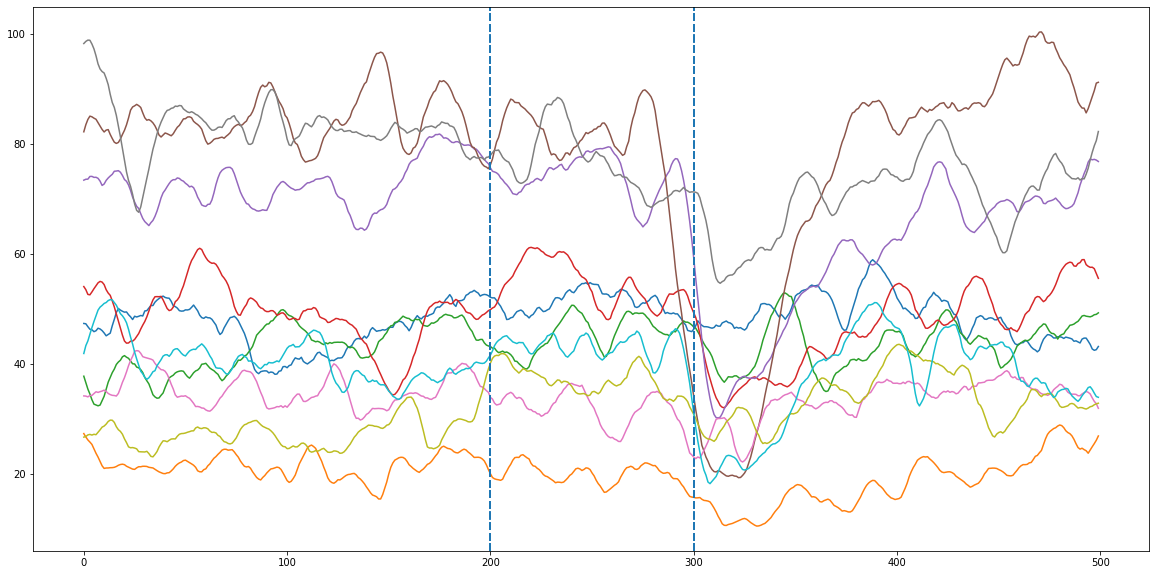

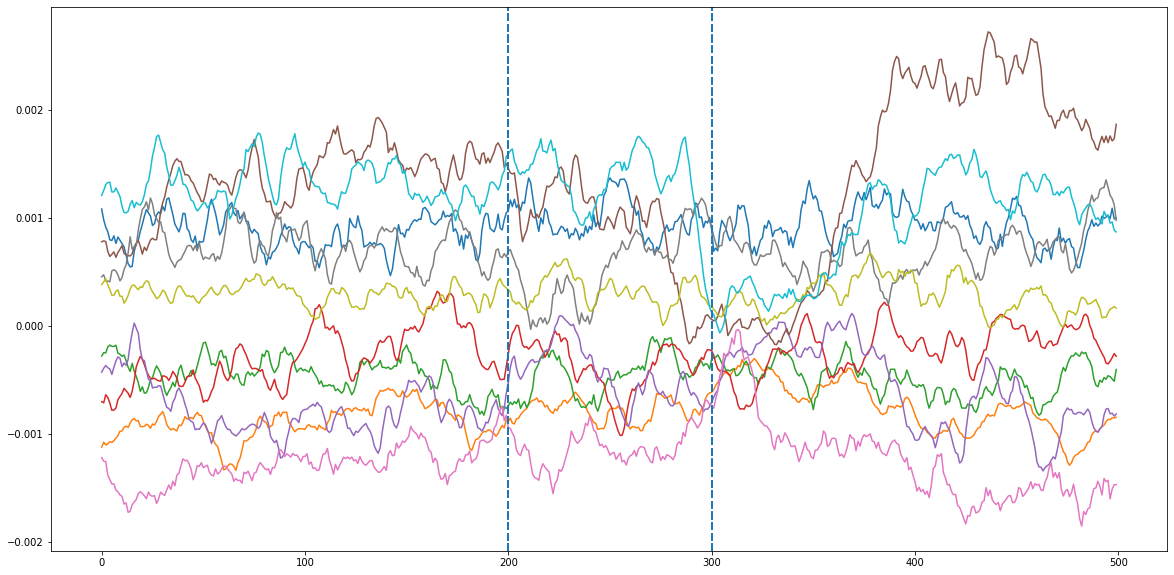

In [11]:
short=['Y', 'Z', 'X']
for s in short:
    fig, ax = plt.subplots(figsize=(20,10))
    for f in fly_nums:
        if s=='Z':
            plt.plot(np.mean(np.abs(all_behave_dict[f'{f}']['behavior'][s]), axis=0).T);
        else:
            plt.plot(np.mean(all_behave_dict[f'{f}']['behavior'][s], axis=0).T);
        ax.axvline(200, linewidth=2, linestyle='--')
        ax.axvline(300, linewidth=2, linestyle='--')

In [12]:
all_behave_dict.keys()

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])

In [13]:
behaviors=['total', 'inc', 'dec', 'flat', 'non']
total_trials={}
pre_post={}
for b in behaviors:
    total_trials[b]={}
    pre_post[b]=[]
    for s in short:
        total_trials[b][s]=[] 

behave_set=all_behave_dict
for fly in behave_set:
    looms=behave_set[fly]['event_times']
    fly_Y=behave_set[fly]['behavior']['Y']
    fly_behavior=behave_set[fly]['behavior']
    behave_set[fly]['labels']=np.full(behave_set[fly]['event_times'].shape,str)
    for i,trial in enumerate(fly_Y):
        pre=np.mean(trial[150:200])
        post=np.mean(trial[250:300])
        total_trials['total']['Y'].append(fly_behavior['Y'][i])
        total_trials['total']['Z'].append(fly_behavior['Z'][i])
        total_trials['total']['X'].append(fly_behavior['X'][i])
        pre_post['total'].append([pre, post])
        if pre>-0.1 and pre<0.1 and post>-0.1 and post<0.1:
            total_trials['flat']['Y'].append(fly_behavior['Y'][i])
            total_trials['flat']['Z'].append(fly_behavior['Z'][i])
            total_trials['flat']['X'].append(fly_behavior['X'][i])
            behave_set[fly]['labels'][i]='flat'
            pre_post['flat'].append([pre, post, i])
#         elif post>np.abs(pre*2):
        elif pre>-1 and pre <0.1 and post>1 and post>np.abs(pre*2):
            total_trials['inc']['Y'].append(fly_behavior['Y'][i])
            total_trials['inc']['Z'].append(fly_behavior['Z'][i])
            total_trials['inc']['X'].append(fly_behavior['X'][i])
            behave_set[fly]['labels'][i]='inc'
            pre_post['inc'].append([pre, post, i])
#         elif post<pre/2:
        elif pre>1 and post<0.1 and post>-1 and post<pre/2:
            total_trials['dec']['Y'].append(fly_behavior['Y'][i])
            total_trials['dec']['Z'].append(fly_behavior['Z'][i])
            total_trials['dec']['X'].append(fly_behavior['X'][i])
            behave_set[fly]['labels'][i]='dec'
            pre_post['dec'].append([pre, post, i])
                
        else:
            total_trials['non']['Y'].append(fly_behavior['Y'][i])
            total_trials['non']['Z'].append(fly_behavior['Z'][i])
            total_trials['non']['X'].append(fly_behavior['X'][i])
            behave_set[fly]['labels'][i]='other'
            pre_post['non'].append([pre, post, i])

In [14]:
for b in total_trials:
    print(f'{b}: {len(total_trials[b]["Y"])}')

total: 1970
inc: 132
dec: 143
flat: 520
non: 1175


In [15]:
total_trials['dec'].keys()

dict_keys(['Y', 'Z', 'X'])

In [16]:
behaves=list(total_trials.keys())

In [17]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#F5F5F5',
    'total': '#F5F5F5',
    'other': '#F5F5F5'
}

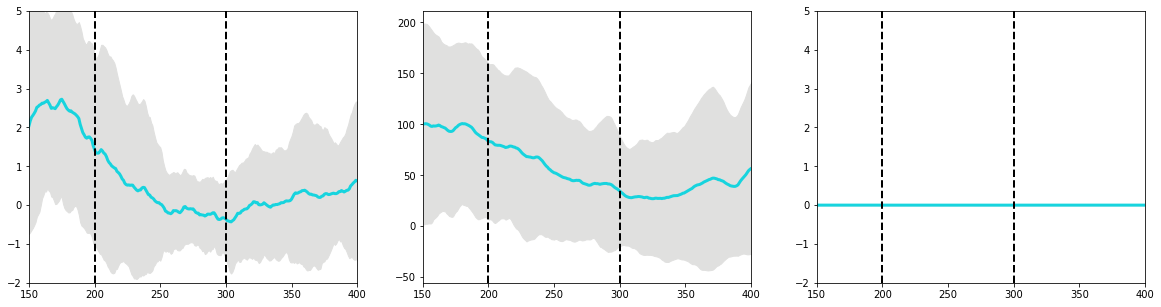

In [18]:
be='dec'
fig,axs=plt.subplots(nrows=1,ncols=len(short),figsize=(20,5))
for i,s in enumerate(short):
    if s=='Z':
        mean_trace=np.mean(np.abs(total_trials[be][s]), axis=0)
        std_trace=np.std(np.abs(total_trials[be][s]), axis=0)
    else:
        mean_trace=np.mean(total_trials[be][s], axis=0)
        std_trace=np.std(total_trials[be][s], axis=0)
    
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    if s!='Z':
        axs[i].set_ylim(-2, 5);
    axs[i].set_xlim(150, 400);

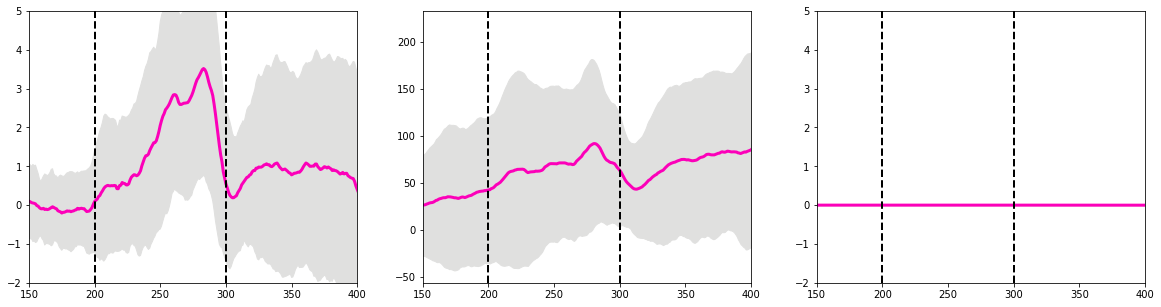

In [19]:
be='inc'
fig,axs=plt.subplots(nrows=1,ncols=len(short),figsize=(20,5))
for i,s in enumerate(short):
    if s=='Z':
        mean_trace=np.mean(np.abs(total_trials[be][s]), axis=0)
        std_trace=np.std(np.abs(total_trials[be][s]), axis=0)
    else:
        mean_trace=np.mean(total_trials[be][s], axis=0)
        std_trace=np.std(total_trials[be][s], axis=0)
    
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    if s!='Z':
        axs[i].set_ylim(-2, 5);
    axs[i].set_xlim(150, 400);

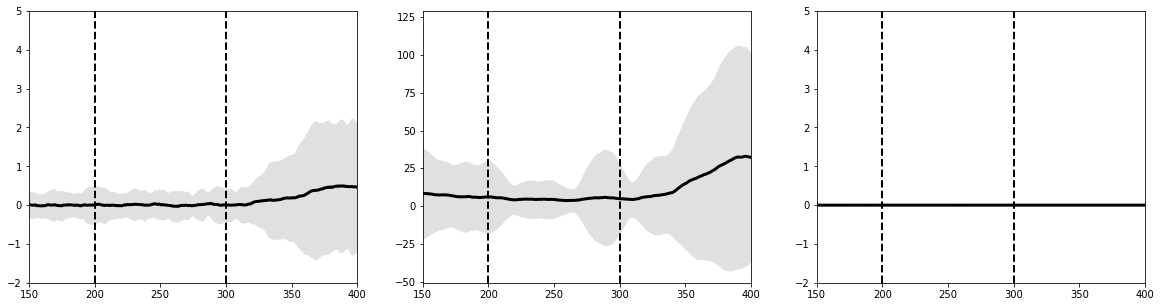

In [20]:
be='flat'
fig,axs=plt.subplots(nrows=1,ncols=len(short),figsize=(20,5))
for i,s in enumerate(short):
    if s=='Z':
        mean_trace=np.mean(np.abs(total_trials[be][s]), axis=0)
        std_trace=np.std(np.abs(total_trials[be][s]), axis=0)
    else:
        mean_trace=np.mean(total_trials[be][s], axis=0)
        std_trace=np.std(total_trials[be][s], axis=0)
    
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    if s!='Z':
        axs[i].set_ylim(-2, 5);
    axs[i].set_xlim(150, 400);

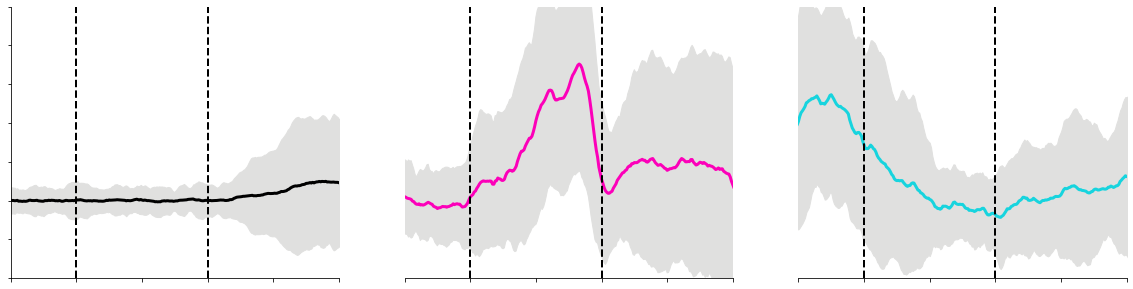

In [21]:
order=[ 'flat','inc', 'dec',]
fig,axs=plt.subplots(nrows=1,ncols=len(order),figsize=(20,5))
for i,be in enumerate(order):
    mean_trace=np.mean(total_trials[be]['Y'], axis=0)
    std_trace=np.std(total_trials[be]['Y'], axis=0)
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    axs[i].set_ylim(-2, 5);
    axs[i].set_xlim(150, 400);
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    if be!='flat':
        axs[i].spines['left'].set_visible(False)
        axs[i].set_yticks([])

In [22]:
target_variance=np.var(np.asarray(total_trials['flat']['Y'])[:,150:200], axis=0)
arr=np.asarray(total_trials['inc']['Y'])[:,150:200]
tolerance=0.1

In [23]:
be='flat'
mean_trace=np.mean(total_trials[be]['Y'], axis=0)[150:200]
std_trace=np.std(total_trials[be]['Y'], axis=0)[150:200]

In [24]:
print(target_variance.shape)
print(arr.shape)

(50,)
(132, 50)


In [25]:
def rank_by_internal_variance(arr, axis=1):
    """
    Rank by the variance within each element (row).
    High internal variance = more spread in that row.
    """
    arr = np.array(arr)
    
    # Variance of each row
    row_variances = np.var(arr, axis=axis)
    
    # Sort by variance (descending)
    rankings = np.argsort(row_variances)[::-1]
    
    return rankings, row_variances

rankings, variances = rank_by_internal_variance(arr)

print("Top 10 by internal variance:")
for i in range(10):
    idx = rankings[i]
    print(f"  Row {idx}: variance = {variances[idx]:.6f}")

Top 10 by internal variance:
  Row 129: variance = 17.005849
  Row 99: variance = 13.877698
  Row 98: variance = 7.492436
  Row 43: variance = 6.814918
  Row 78: variance = 6.811801
  Row 38: variance = 6.591325
  Row 25: variance = 5.242244
  Row 65: variance = 4.375073
  Row 74: variance = 3.869742
  Row 15: variance = 3.360107


In [26]:
np.std(np.asarray(total_trials['inc']['Y'])[:,150:200][rankings[70:],:])

0.2205557875121434

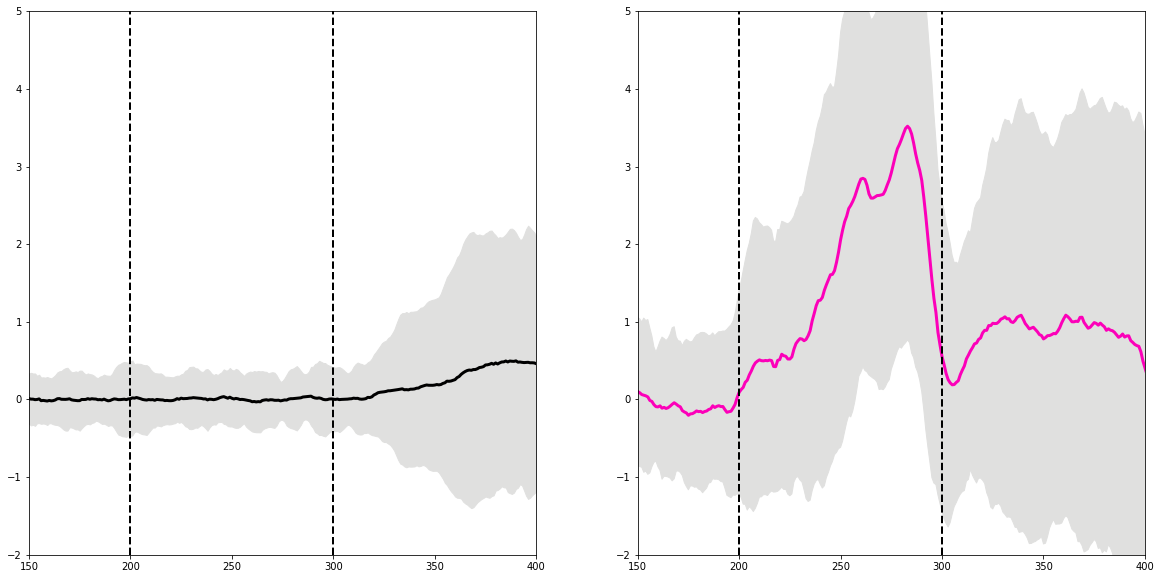

In [27]:

s='Y'
fig,axs=plt.subplots(nrows=1,ncols=2,figsize=(20,10))
be='flat'
mean_trace=np.mean(total_trials[be][s], axis=0)
std_trace=np.std(total_trials[be][s], axis=0)
axs[0].plot(mean_trace, color=behavior_colors[be],lw=3)
axs[0].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
axs[0].axvline(200, linewidth=2, linestyle='--', color='k')
axs[0].axvline(300, linewidth=2, linestyle='--', color='k')
axs[0].set_ylim(-2, 5);
axs[0].set_xlim(150, 400);
be='inc'
mean_trace=np.mean(total_trials[be][s], axis=0)
std_trace=np.std(total_trials[be][s], axis=0)
axs[1].plot(mean_trace, color=behavior_colors[be],lw=3)
axs[1].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
axs[1].axvline(200, linewidth=2, linestyle='--', color='k')
axs[1].axvline(300, linewidth=2, linestyle='--', color='k')
axs[1].set_ylim(-2, 5);
axs[1].set_xlim(150, 400);

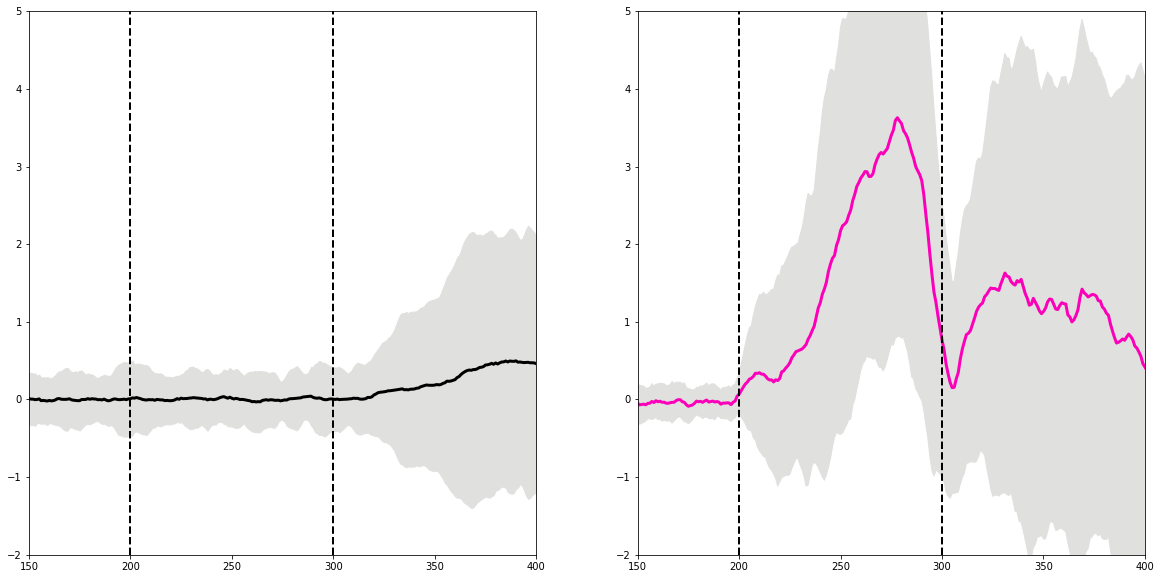

In [28]:
s='Y'
fig,axs=plt.subplots(nrows=1,ncols=2,figsize=(20,10))
be='flat'
mean_trace=np.mean(total_trials[be][s], axis=0)
std_trace=np.std(total_trials[be][s], axis=0)
axs[0].plot(mean_trace, color=behavior_colors[be],lw=3)
axs[0].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
axs[0].axvline(200, linewidth=2, linestyle='--', color='k')
axs[0].axvline(300, linewidth=2, linestyle='--', color='k')
axs[0].set_ylim(-2, 5);
axs[0].set_xlim(150, 400);
be='inc'
mean_trace=np.mean(np.asarray(total_trials[be][s])[rankings[70:],:], axis=0)
std_trace=np.std(np.asarray(total_trials[be][s])[rankings[70:],:], axis=0)
axs[1].plot(mean_trace, color=behavior_colors[be],lw=3)
axs[1].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
axs[1].axvline(200, linewidth=2, linestyle='--', color='k')
axs[1].axvline(300, linewidth=2, linestyle='--', color='k')
axs[1].set_ylim(-2, 5);
axs[1].set_xlim(150, 400);

In [29]:
behave_set['250'].keys()

dict_keys(['timestamps', 'event_times', 'behavior', 'labels'])

In [30]:
behave_set['250']['behavior']['Y'].shape

(197, 500)

In [31]:
np.unique(behave_set['250']['labels'])

array(['dec', 'flat', 'inc', 'other'], dtype=object)

In [32]:
labs=np.unique(behave_set['250']['labels'])
types={}
for b in labs:
    types[b]={}
    for be in labs:
        types[b][be]=0
    types[b]['total']=0

In [33]:
for fly in behave_set:
    if fly!='227':
        fly_behaves=behave_set[fly]['labels']
        for i,trial in enumerate(fly_behaves):
            types[trial]['total']+=1
            if i+1<fly_behaves.shape[0]:
                next_type=fly_behaves[i+1]
                types[trial][next_type]+=1

In [34]:
def make_types_count(behave_set, start=None,end=None):
    key=np.array(list(behave_set.keys()))[-1]
    labs=np.unique(behave_set[key]['labels'])
    types={}
    for b in labs:
        types[b]={}
        for be in labs:
            types[b][be]=0
        types[b]['total']=0
    for fly in behave_set:
        if fly!='227':
            if start==None and end==None:
                fly_behaves=behave_set[fly]['labels']
            else:
                fly_behaves=behave_set[fly]['labels'][start:end]
            for i,trial in enumerate(fly_behaves):
                types[trial]['total']+=1
                if i+1<fly_behaves.shape[0]:
                    next_type=fly_behaves[i+1]
                    types[trial][next_type]+=1
    return types

In [35]:
types=make_types_count(behave_set)

In [36]:
types_2={}
labels=[]
for b in types:
    types_2[b]=[]
    for be in types[b]:
        if be!='total':
            labels.append(be)
            per=types[b][be]/types[b]['total']
            types_2[b].append(per)
labels=np.unique(labels)

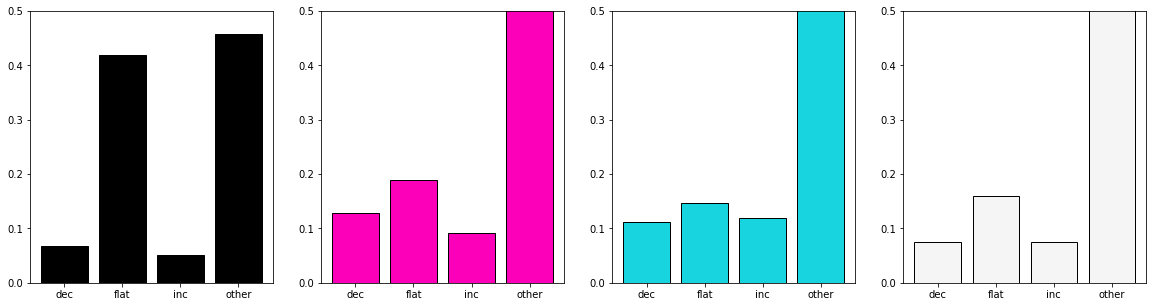

In [37]:
fig,axs=plt.subplots(nrows=1,ncols=4,figsize=(20,5))
be='flat'
axs[0].bar(labels,types_2[be],color=behavior_colors[be],edgecolor='k');
axs[0].set_ylim(0, 0.5);
be='inc'
axs[1].bar(labels,types_2[be],color=behavior_colors[be],edgecolor='k');
axs[1].set_ylim(0, 0.5);
be='dec'
axs[2].bar(labels,types_2[be],color=behavior_colors[be],edgecolor='k');
axs[2].set_ylim(0,0.5);
be='other'
axs[3].bar(labels,types_2[be],color=behavior_colors[be],edgecolor='k');
axs[3].set_ylim(0, 0.5);

In [38]:
prestim_Y_mean=[]
trial_lab=[]
for fly in behave_set:
    prestim_Y=np.asarray(behave_set[fly]['behavior']['Y'])[:,150:200]
    prestim_Y_mean.append(np.mean(prestim_Y,axis=-1))
    trial_lab.append(behave_set[fly]['labels'])
pym=np.hstack(prestim_Y_mean)
tl=np.hstack(trial_lab)

In [39]:
sort_idx=np.argsort(pym)
sort_pym=pym[sort_idx]
sort_tl=tl[sort_idx]
point_colors = [behavior_colors[label] for label in sort_tl]

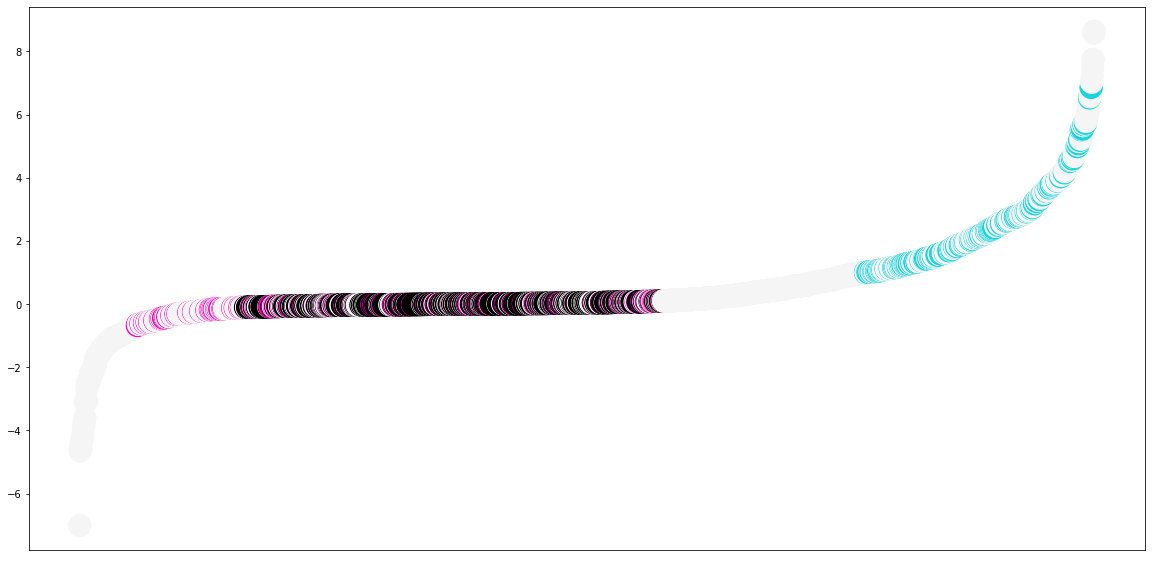

In [40]:
fig,axs=plt.subplots(figsize=(20,10))
axs.scatter(range(len(sort_pym)), sort_pym,s=500,c=point_colors);
axs.set_xticks([]);

In [41]:
def make_snakey_plot(types):
    labels = list(types.keys())      # your state order
    n = len(labels)

    # indices for duplicated nodes
    idx_from = {lab: i for i, lab in enumerate(labels)}        # 0..n-1
    idx_to   = {lab: i + n for i, lab in enumerate(labels)}    # n..2n-1

    sources, targets, values, link_colors = [], [], [], []

    for frm, arr in types.items():
        for to, v in arr.items():
            if frm!='total' and to!='total':
                sources.append(idx_from[frm])        # left column
                targets.append(idx_to[to])           # right column
                values.append(v)
                link_colors.append(behavior_colors[frm])  # color by FROM

    # Force a 2-column layout (left = From, right = To)
    x = [0.02]*n + [0.98]*n
    y = list(np.linspace(0.02, 0.98, n)) + list(np.linspace(0.02, 0.98, n))

    fig = go.Figure(go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=5,
            thickness=20,
            line=dict(color="black", width=0.3),
            label=labels,  # duplicated labels
            color=[behavior_colors[l] for l in labels] + [behavior_colors[l] for l in labels],
            x=x, y=y
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
            line=dict(color="black", width=0.3)
        )
    ))

    # fig.update_layout(title="Transitions", font_size=16)
    return fig

In [42]:
types_start=make_types_count(behave_set, start=0,end=50)
fig2=make_snakey_plot(types_start)
fig2.show()

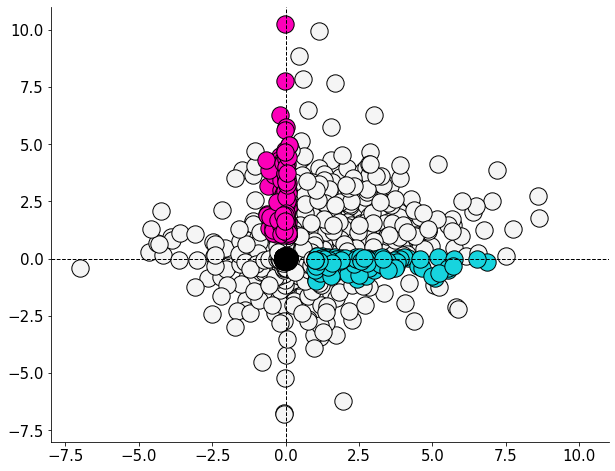

In [43]:
fig,ax=plt.subplots(figsize=(10, 8))
behavior_set=pre_post
order=['non','inc','dec','flat']
for key in order:
    ax.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=300,color=behavior_colors[key], edgecolor='k', label=key);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
# ax.set_xticklabels([]);
# ax.set_yticklabels([]);
ax.set_xlim(-8,11)
ax.set_ylim(-8,11)
plt.axvline(0,color='k',linestyle='--',lw=1);
plt.axhline(0,color='k',linestyle='--',lw=1);
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)

In [44]:
def blend_with_white(hex_color, t):
    """
    t in [0,1]: 0 -> original color, 1 -> white
    """
    rgb = np.array(mcolors.to_rgb(hex_color))
    white = np.array([1., 1., 1.])
    return (1 - t) * rgb + t * white

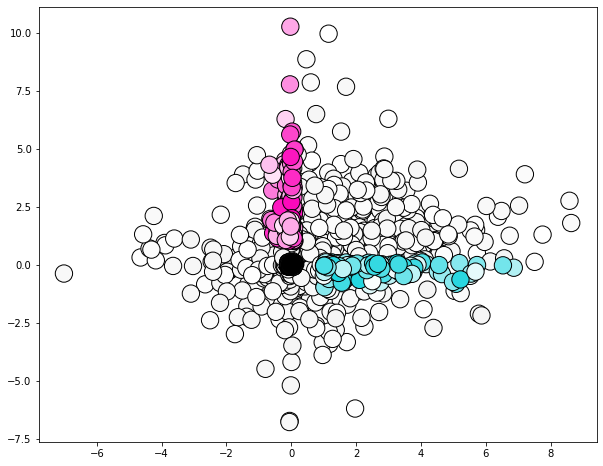

In [45]:
fig, ax = plt.subplots(figsize=(10, 8))

behavior_set = pre_post
order = ['non', 'inc', 'dec', 'flat']

for key in order:
    arr = np.asarray(behavior_set[key])  # columns: x, y, trial
    x, y, trial = arr[:, 0], arr[:, 1], arr[:, 2]
    # map trial 1..200 -> whiteness 1..0 (trial=1 is lightest)
    w = 1 - (trial - 1) / (np.max(trial) - 1)          # w in [0,1]
    # optional: don’t wash out completely
    w = 0.99 * w

    colors = [blend_with_white(behavior_colors[key], wi) for wi in w]

    ax.scatter(x, y, s=300, c=colors, edgecolor='k', label=key)

plt.show()